In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yaml
from pathlib import Path

In [2]:
config_path = Path.cwd().parent / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

root = Path(config['project_root'])

In [3]:
df= pd.read_csv(root / "data" / "processed" / "air_quality_bilbao_2012_2026.csv")
df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_16640\3869169793.py:1: DtypeWarning: Columns (0: NO (µg/m3)) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(root / "data" / "processed" / "air_quality_bilbao_2012_2026.csv")


,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,station,CO (mg/m3),PM10 (µg/m3),...,SH2 (µg/m3),M-P-XILENO (µg/m3),CO 8h (mg/m3),Etilbenceno (µg/m3),O3 8h (µg/m3),Province,Town,Address,Latitude,Longitude
0,31/12/2012,2.0,6.0,9.0,80.0,14.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
1,30/12/2012,2.0,6.0,8.0,69.0,9.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
2,29/12/2012,2.0,9.0,11.0,76.0,10.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
3,28/12/2012,5.0,14.0,22.0,67.0,14.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
4,27/12/2012,2.0,11.0,14.0,58.0,18.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


In [4]:
df.isnull().sum()

Date                       0
NO (µg/m3)              2704
NO2 (µg/m3)             2820
NOX (µg/m3)             3794
O3 (µg/m3)             34956
SO2 (µg/m3)             9764
year                       0
station                    0
CO (mg/m3)             33150
PM10 (µg/m3)            4820
PM2,5 (µg/m3)          25106
Benceno (µg/m3)        43226
Ortoxileno (µg/m3)     47300
Tolueno (µg/m3)        43131
NH3 (µg/m3)            47746
SH2 (µg/m3)            45435
M-P-XILENO (µg/m3)     47953
CO 8h (mg/m3)          36832
Etilbenceno (µg/m3)    48184
O3 8h (µg/m3)          42104
Province                1096
Town                    1096
Address                 1096
Latitude                1096
Longitude               1096
dtype: int64

In [5]:
df[df['Town'].isna()]

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,station,CO (mg/m3),PM10 (µg/m3),...,SH2 (µg/m3),M-P-XILENO (µg/m3),CO 8h (mg/m3),Etilbenceno (µg/m3),O3 8h (µg/m3),Province,Town,Address,Latitude,Longitude
15229,31/12/2016,NaN,NaN,NaN,NaN,1.0,2016,ANORGA,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15230,30/12/2016,NaN,NaN,NaN,NaN,4.0,2016,ANORGA,NaN,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15231,29/12/2016,NaN,NaN,NaN,NaN,1.0,2016,ANORGA,NaN,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15232,28/12/2016,NaN,NaN,NaN,NaN,2.0,2016,ANORGA,NaN,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15233,27/12/2016,NaN,NaN,NaN,NaN,2.0,2016,ANORGA,NaN,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26535,05/01/2019,39.0,39.0,97.0,8.0,3.0,2019,ANDOAIN,NaN,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26536,04/01/2019,44.0,38.0,104.0,9.0,4.0,2019,ANDOAIN,NaN,32.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26537,03/01/2019,35.0,36.0,88.0,11.0,3.0,2019,ANDOAIN,NaN,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26538,02/01/2019,9.0,33.0,45.0,19.0,3.0,2019,ANDOAIN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.groupby("station")["Town"].unique()

station
ABANTO            [Abanto y Ciérvana-Abanto Zierbena]
ALGORTA_BBIZI2                                [Getxo]
ALONSOTEGI                               [Alonsotegi]
ANDOAIN                                         [nan]
ANORGA                                          [nan]
BARAKALDO                                 [Barakaldo]
BASAURI                                     [Basauri]
ERANDIO                                     [Erandio]
MAZARREDO                                    [Bilbao]
MUSKIZ                                       [Muskiz]
SANGRONIZ                                   [Sondika]
SANTURCE                                  [Santurtzi]
SAN_JULIAN                                      [nan]
Name: Town, dtype: object

In [7]:
df = df[(df["station"] != "SAN_JULIAN") & (df["station"] != "ANDOAIN")& (df["station"] != "ANORGA")]
df.head()

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,station,CO (mg/m3),PM10 (µg/m3),...,SH2 (µg/m3),M-P-XILENO (µg/m3),CO 8h (mg/m3),Etilbenceno (µg/m3),O3 8h (µg/m3),Province,Town,Address,Latitude,Longitude
0,31/12/2012,2.0,6.0,9.0,80.0,14.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
1,30/12/2012,2.0,6.0,8.0,69.0,9.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
2,29/12/2012,2.0,9.0,11.0,76.0,10.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
3,28/12/2012,5.0,14.0,22.0,67.0,14.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
4,27/12/2012,2.0,11.0,14.0,58.0,18.0,2012,ABANTO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


In [8]:
df.isnull().sum()

Date                       0
NO (µg/m3)              2640
NO2 (µg/m3)             2756
NOX (µg/m3)             3730
O3 (µg/m3)             34577
SO2 (µg/m3)             9719
year                       0
station                    0
CO (mg/m3)             32054
PM10 (µg/m3)            4762
PM2,5 (µg/m3)          24685
Benceno (µg/m3)        42483
Ortoxileno (µg/m3)     46204
Tolueno (µg/m3)        42388
NH3 (µg/m3)            46650
SH2 (µg/m3)            44686
M-P-XILENO (µg/m3)     47210
CO 8h (mg/m3)          35736
Etilbenceno (µg/m3)    47088
O3 8h (µg/m3)          41360
Province                   0
Town                       0
Address                    0
Latitude                   0
Longitude                  0
dtype: int64

In [9]:
main_town = df.groupby("station")["Town"].agg(lambda x: x.mode()[0])
main_town

station
ABANTO            Abanto y Ciérvana-Abanto Zierbena
ALGORTA_BBIZI2                                Getxo
ALONSOTEGI                               Alonsotegi
BARAKALDO                                 Barakaldo
BASAURI                                     Basauri
ERANDIO                                     Erandio
MAZARREDO                                    Bilbao
MUSKIZ                                       Muskiz
SANGRONIZ                                   Sondika
SANTURCE                                  Santurtzi
Name: Town, dtype: str

In [10]:
df.select_dtypes(include="object").info()


<class 'pandas.DataFrame'>
Index: 51162 entries, 0 to 52257
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 51162 non-null  str   
 1   NO (µg/m3)           48522 non-null  object
 2   station              51162 non-null  str   
 3   CO (mg/m3)           19108 non-null  str   
 4   Benceno (µg/m3)      8679 non-null   str   
 5   Ortoxileno (µg/m3)   4958 non-null   str   
 6   Tolueno (µg/m3)      8774 non-null   str   
 7   M-P-XILENO (µg/m3)   3952 non-null   str   
 8   CO 8h (mg/m3)        15426 non-null  str   
 9   Etilbenceno (µg/m3)  4074 non-null   str   
 10  Province             51162 non-null  str   
 11  Town                 51162 non-null  str   
 12  Address              51162 non-null  str   
dtypes: object(1), str(12)
memory usage: 9.1+ MB


C:\Users\Dell\AppData\Local\Temp\ipykernel_16640\1287950312.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").info()


In [11]:
# Convert numeric columns that are stored as objects to numeric types, handling commas as decimal separators

df = df.copy()

numeric_object_cols = [
    "NO (µg/m3)", "CO (mg/m3)", "Benceno (µg/m3)", "Ortoxileno (µg/m3)",
    "Tolueno (µg/m3)", "M-P-XILENO (µg/m3)", "CO 8h (mg/m3)", "Etilbenceno (µg/m3)"
]

for col in numeric_object_cols:
    df[col] = df[col].astype("object")

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

df.info()

<class 'pandas.DataFrame'>
Index: 51162 entries, 0 to 52257
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 51162 non-null  str    
 1   NO (µg/m3)           48522 non-null  float64
 2   NO2 (µg/m3)          48406 non-null  float64
 3   NOX (µg/m3)          47432 non-null  float64
 4   O3 (µg/m3)           16585 non-null  float64
 5   SO2 (µg/m3)          41443 non-null  float64
 6   year                 51162 non-null  int64  
 7   station              51162 non-null  str    
 8   CO (mg/m3)           19108 non-null  float64
 9   PM10 (µg/m3)         46400 non-null  float64
 10  PM2,5 (µg/m3)        26477 non-null  float64
 11  Benceno (µg/m3)      8679 non-null   float64
 12  Ortoxileno (µg/m3)   4958 non-null   float64
 13  Tolueno (µg/m3)      8774 non-null   float64
 14  NH3 (µg/m3)          4512 non-null   float64
 15  SH2 (µg/m3)          6476 non-null   float64
 16  M-

M-P-XILENO (µg/m3)     92.275517
Etilbenceno (µg/m3)    92.037059
NH3 (µg/m3)            91.180955
Ortoxileno (µg/m3)     90.309214
SH2 (µg/m3)            87.342168
Benceno (µg/m3)        83.036238
Tolueno (µg/m3)        82.850553
O3 8h (µg/m3)          80.841249
CO 8h (mg/m3)          69.848716
O3 (µg/m3)             67.583363
CO (mg/m3)             62.651968
PM2,5 (µg/m3)          48.248700
SO2 (µg/m3)            18.996521
PM10 (µg/m3)            9.307689
NOX (µg/m3)             7.290567
NO2 (µg/m3)             5.386811
NO (µg/m3)              5.160080
station                 0.000000
year                    0.000000
Date                    0.000000
Province                0.000000
Town                    0.000000
Address                 0.000000
Latitude                0.000000
Longitude               0.000000
dtype: float64


Text(0.5, 1.0, 'Percentage of Missing Values by Column')

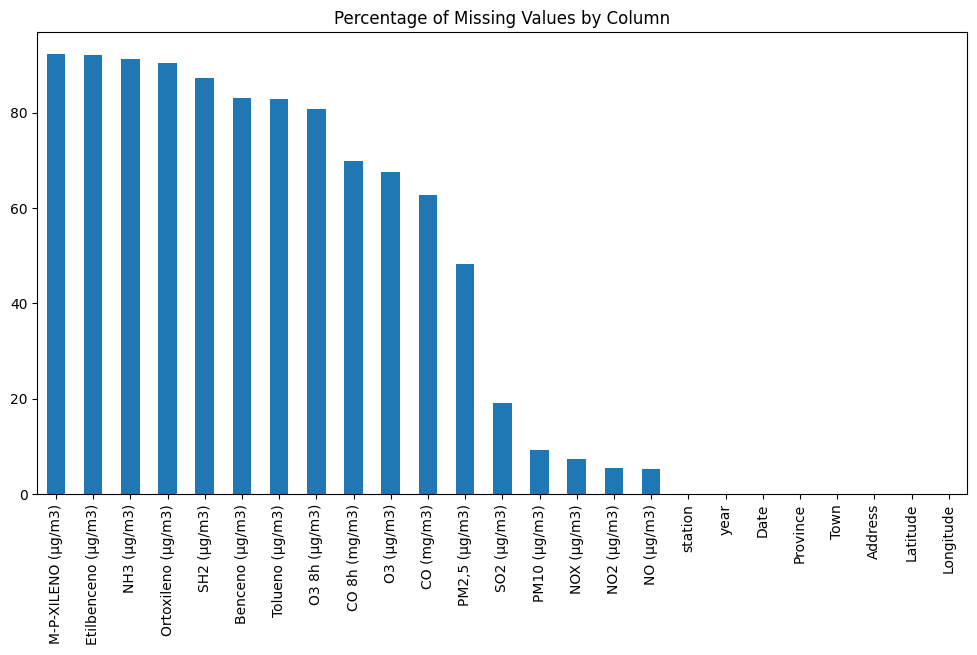

In [12]:
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
print (missing_percent)
missing_percent.plot(kind="bar", figsize=(12, 6))
plt.title("Percentage of Missing Values by Column")

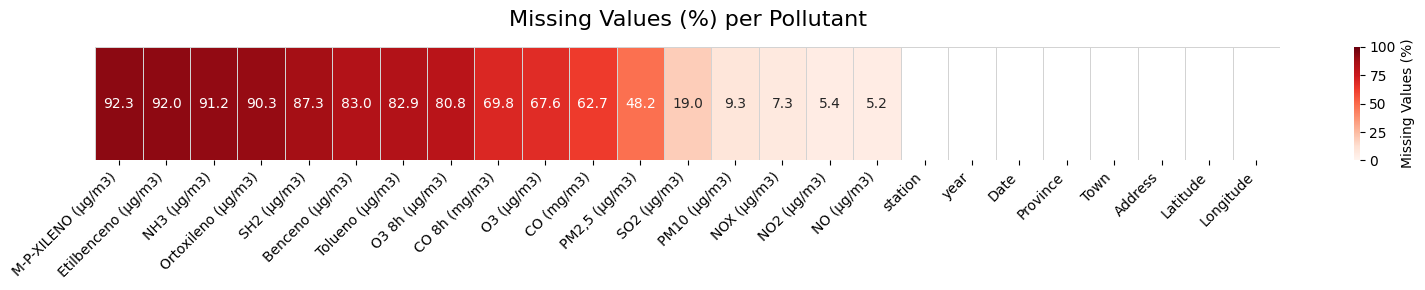

In [13]:
missing_percent_df = missing_percent.to_frame().T


mask = missing_percent_df == 0

plt.figure(figsize=(16, 3))

sns.heatmap(
    missing_percent_df,
    mask=mask,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing Values (%) per Pollutant", fontsize=16, pad=15)

plt.xticks(rotation=45, ha="right")
plt.yticks([])

plt.tight_layout()
plt.show()

In [14]:
#!pip install missingno

<Axes: >

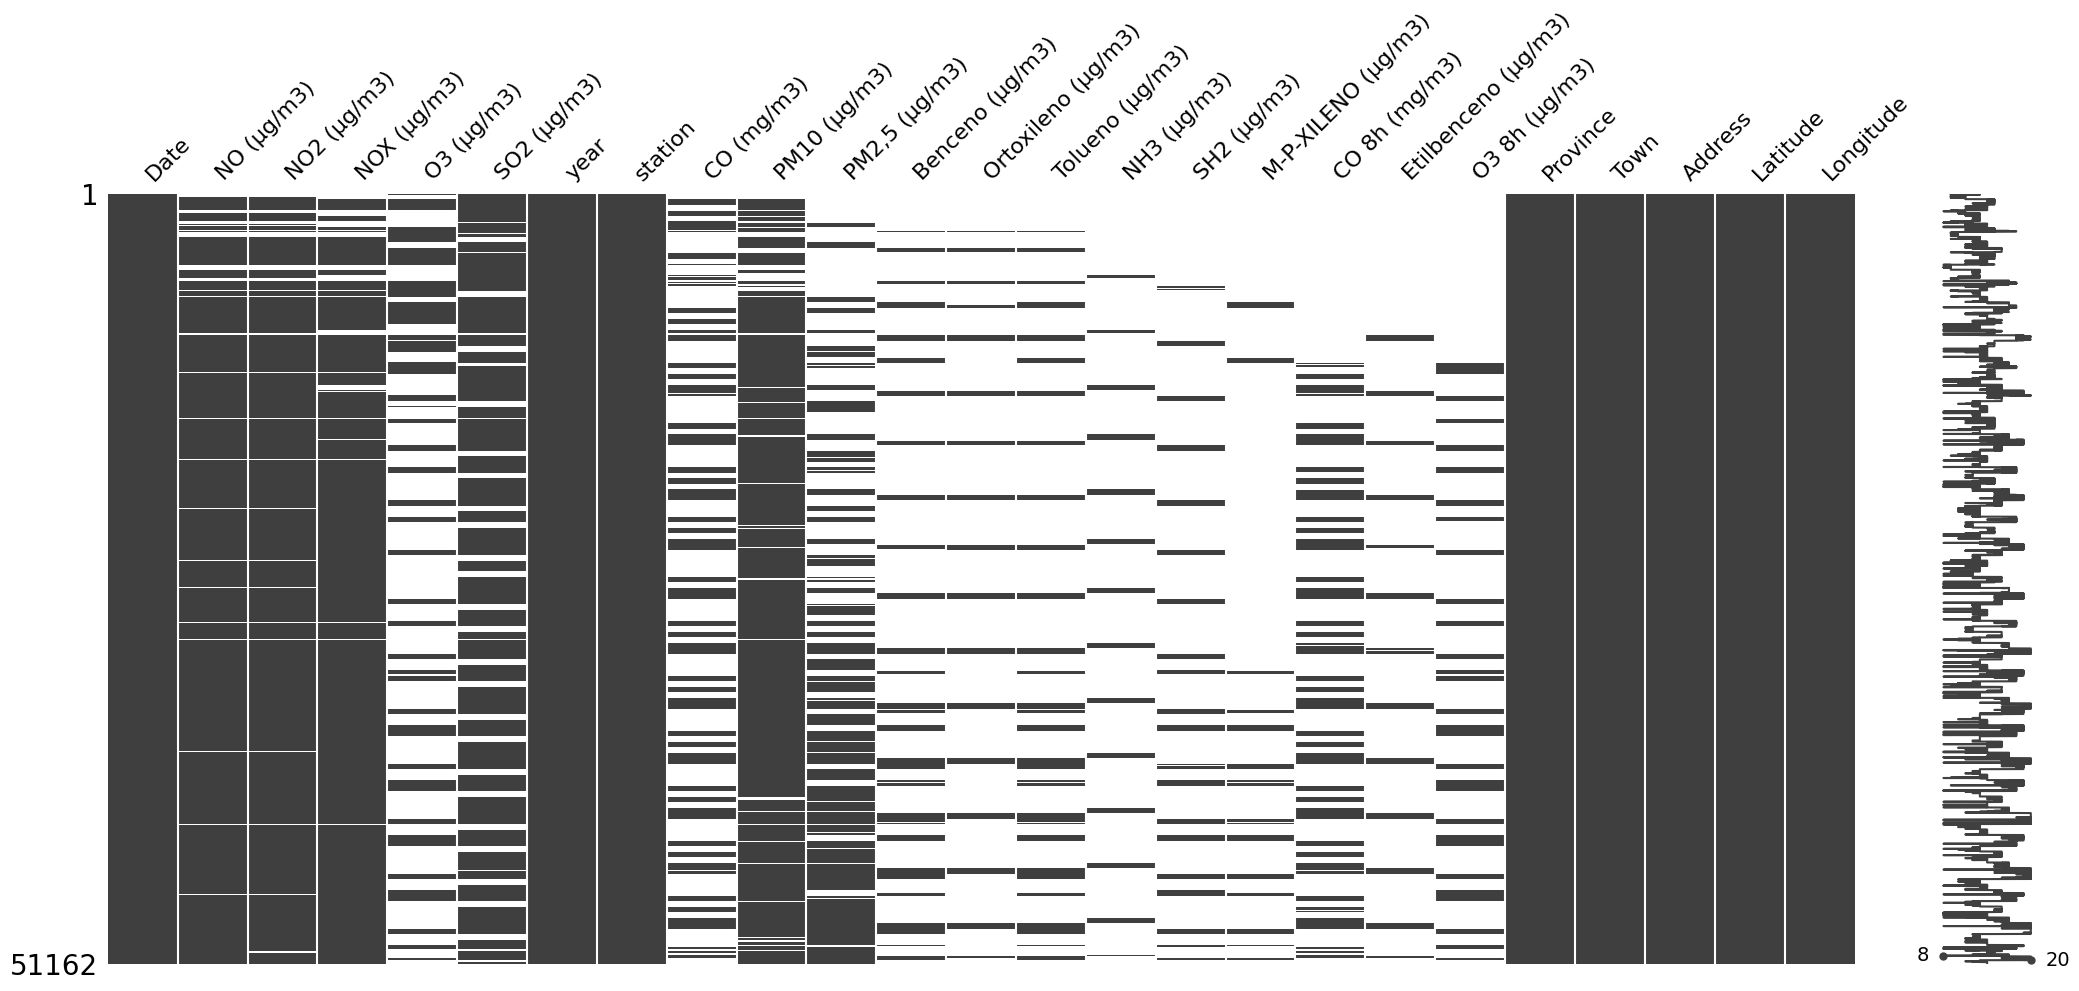

In [15]:
import missingno as msno
msno.matrix(df)

<Axes: >

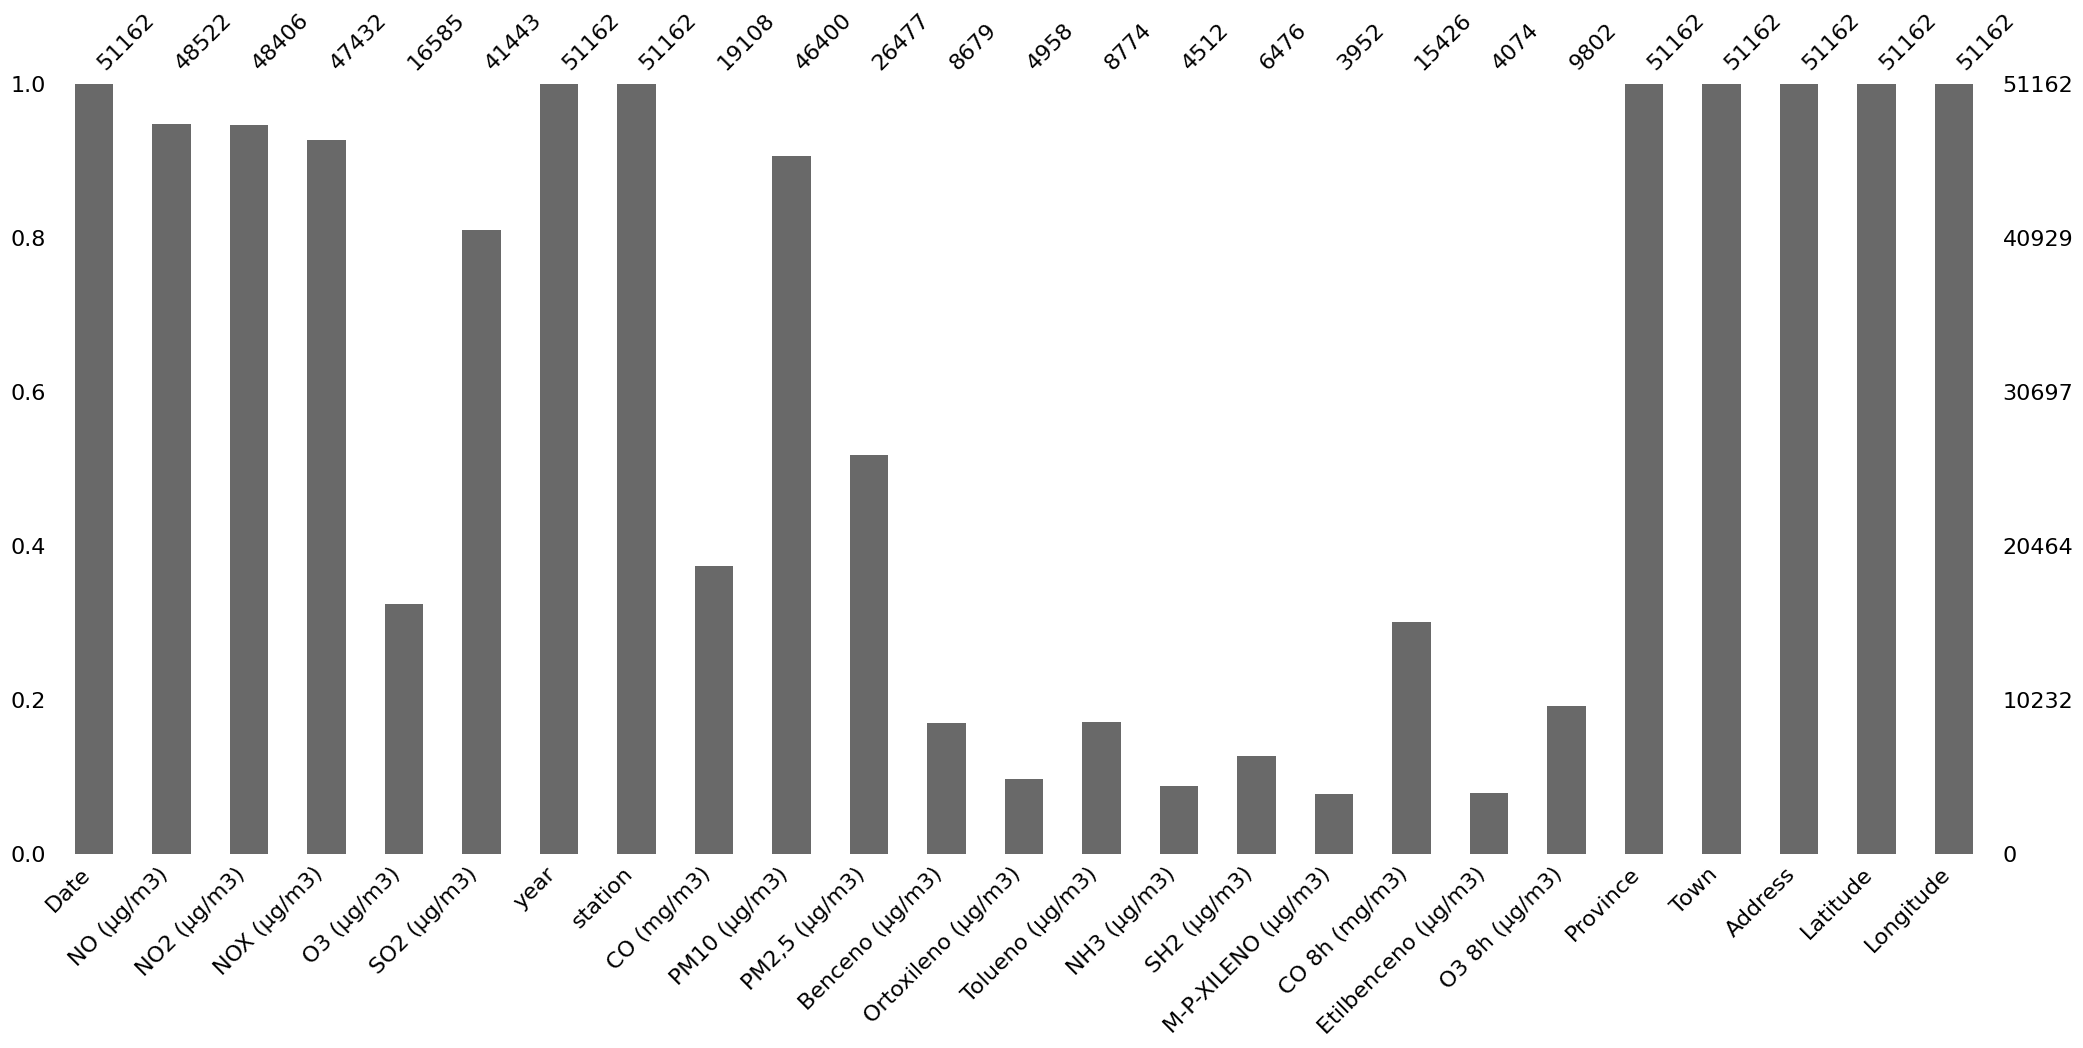

In [16]:
msno.bar(df)

In [17]:
cols_to_drop = missing_percent[missing_percent > 70].index
cols_to_drop

Index(['M-P-XILENO (µg/m3)', 'Etilbenceno (µg/m3)', 'NH3 (µg/m3)',
       'Ortoxileno (µg/m3)', 'SH2 (µg/m3)', 'Benceno (µg/m3)',
       'Tolueno (µg/m3)', 'O3 8h (µg/m3)'],
      dtype='str')

In [18]:
# Drop columns with more than 70% missing values
df_70 = df.drop(columns=cols_to_drop)
df_70.head()   

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,station,CO (mg/m3),PM10 (µg/m3),"PM2,5 (µg/m3)",CO 8h (mg/m3),Province,Town,Address,Latitude,Longitude
0,31/12/2012,2.0,6.0,9.0,80.0,14.0,2012,ABANTO,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
1,30/12/2012,2.0,6.0,8.0,69.0,9.0,2012,ABANTO,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
2,29/12/2012,2.0,9.0,11.0,76.0,10.0,2012,ABANTO,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
3,28/12/2012,5.0,14.0,22.0,67.0,14.0,2012,ABANTO,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
4,27/12/2012,2.0,11.0,14.0,58.0,18.0,2012,ABANTO,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


In [19]:
df_70.isnull().sum()

Date                 0
NO (µg/m3)        2640
NO2 (µg/m3)       2756
NOX (µg/m3)       3730
O3 (µg/m3)       34577
SO2 (µg/m3)       9719
year                 0
station              0
CO (mg/m3)       32054
PM10 (µg/m3)      4762
PM2,5 (µg/m3)    24685
CO 8h (mg/m3)    35736
Province             0
Town                 0
Address              0
Latitude             0
Longitude            0
dtype: int64

Now decide on the decision for CO 8h, O3, CO, PM2.5

In [20]:
missing_by_station= df_70.groupby("station").apply(lambda x: x.isna().mean()*100)
missing_by_station

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,CO (mg/m3),PM10 (µg/m3),"PM2,5 (µg/m3)",CO 8h (mg/m3),Province,Town,Address,Latitude,Longitude
station,,,,,,,,,,,,,,,,
ABANTO,0.0,3.914045,3.722180,6.523408,50.326170,1.995395,0.0,100.000000,16.174213,100.000000,100.000000,0.0,0.0,0.0,0.0,0.0
ALGORTA_BBIZI2,0.0,1.868743,1.824249,1.868743,1.757508,6.340378,0.0,2.914349,3.492770,19.065628,28.542825,0.0,0.0,0.0,0.0,0.0
ALONSOTEGI,0.0,1.564885,1.698473,1.450382,65.209924,65.152672,0.0,100.000000,2.996183,67.919847,100.000000,0.0,0.0,0.0,0.0,0.0
BARAKALDO,0.0,13.072519,15.114504,15.629771,92.213740,2.003817,0.0,8.339695,16.889313,53.072519,21.793893,0.0,0.0,0.0,0.0,0.0
BASAURI,0.0,2.894939,3.182515,2.760736,100.000000,2.434816,0.0,100.000000,7.611196,70.878067,100.000000,0.0,0.0,0.0,0.0,0.0
ERANDIO,0.0,12.213740,12.232824,29.618321,100.000000,2.900763,0.0,4.026718,15.667939,13.702290,22.290076,0.0,0.0,0.0,0.0,0.0
MAZARREDO,0.0,1.758746,1.739629,1.701396,79.296502,2.141082,0.0,6.098260,7.264385,55.993118,22.691646,0.0,0.0,0.0,0.0,0.0
MUSKIZ,0.0,8.541747,8.541747,8.426318,0.750289,2.770296,0.0,100.000000,13.889958,76.587149,100.000000,0.0,0.0,0.0,0.0,0.0
SANGRONIZ,0.0,3.132162,3.151261,1.795264,78.857907,100.000000,0.0,100.000000,4.258976,15.966387,100.000000,0.0,0.0,0.0,0.0,0.0


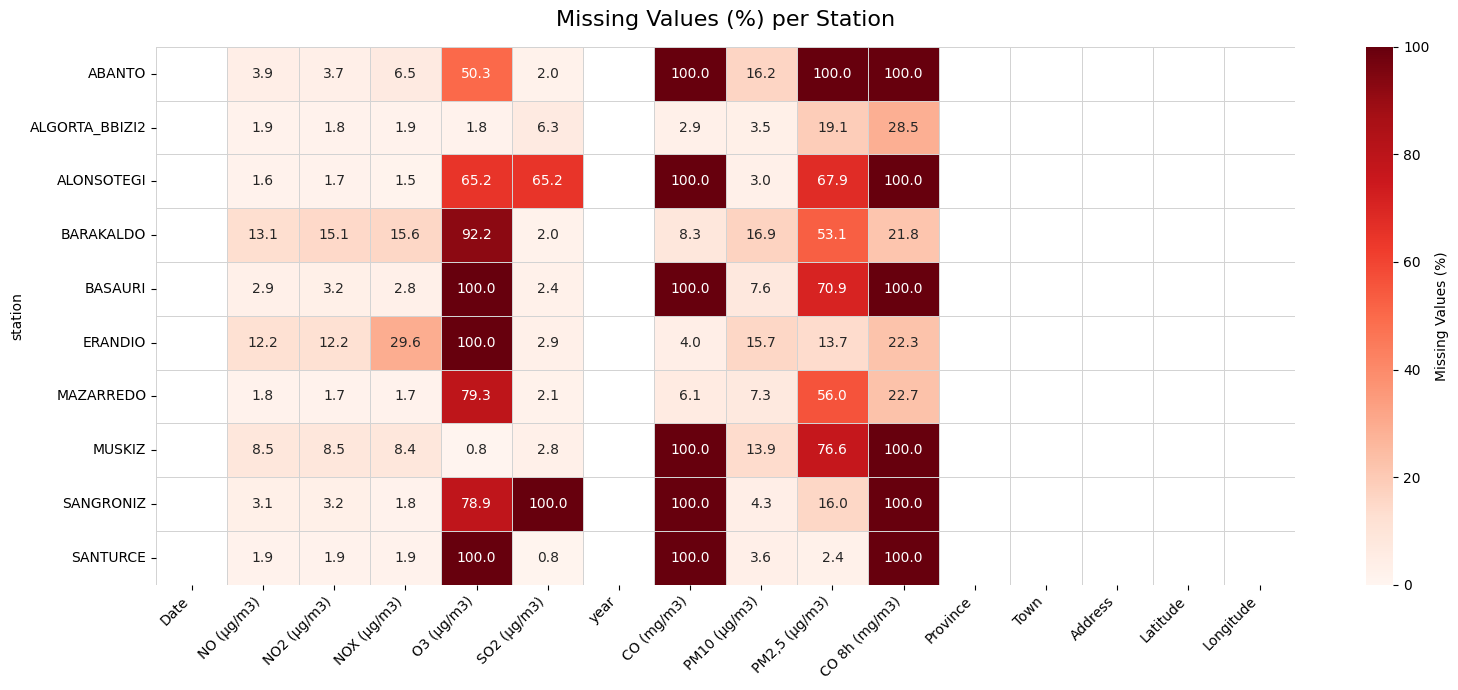

In [21]:
mask = missing_by_station == 0

plt.figure(figsize=(16, 7))

sns.heatmap(
    missing_by_station,
    mask=mask,                 # hide unnecessary cells
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing Values (%) per Station", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

C:\Users\Dell\AppData\Local\Temp\ipykernel_16640\3693147909.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [23]:
df_70 = df_70.copy()
df_70["Date"] = pd.to_datetime(df_70["Date"], errors="coerce")

missing_by_year = (
    df_70
    .assign(year=df_70["Date"].dt.year)
    .groupby("year")
    .apply(lambda x: x.isna().mean()*100)
)
missing_by_year

C:\Users\Dell\AppData\Local\Temp\ipykernel_16640\8947755.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_70["Date"] = pd.to_datetime(df_70["Date"], errors="coerce")


,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),station,CO (mg/m3),PM10 (µg/m3),"PM2,5 (µg/m3)",CO 8h (mg/m3),Province,Town,Address,Latitude,Longitude
year,,,,,,,,,,,,,,,,
2012,0.0,27.516030,27.488152,39.448007,49.289100,14.441037,0.0,63.172568,34.290493,81.209925,100.000000,0.0,0.0,0.0,0.0,0.0
2013,0.0,18.421053,18.393352,23.130194,40.055402,14.764543,0.0,75.429363,49.279778,89.861496,100.000000,0.0,0.0,0.0,0.0,0.0
2014,0.0,4.575342,4.575342,11.342466,30.630137,13.726027,0.0,63.972603,6.164384,65.534247,99.589041,0.0,0.0,0.0,0.0,0.0
2015,0.0,1.452055,1.452055,11.452055,67.643836,17.150685,0.0,62.054795,2.849315,61.753425,63.397260,0.0,0.0,0.0,0.0,0.0
2016,0.0,4.189435,4.584092,5.464481,77.838494,12.446873,0.0,66.848816,3.976928,67.668488,67.273831,0.0,0.0,0.0,0.0,0.0
2017,0.0,2.770167,2.770167,0.882801,77.899543,23.074581,0.0,56.042618,3.500761,67.640791,57.047184,0.0,0.0,0.0,0.0,0.0
2018,0.0,2.226498,2.199010,1.072018,80.236394,20.643211,0.0,60.225399,3.188565,61.682243,60.802639,0.0,0.0,0.0,0.0,0.0
2019,0.0,2.039574,1.978691,1.856925,88.949772,23.257230,0.0,67.062405,6.514460,61.400304,67.123288,0.0,0.0,0.0,0.0,0.0
2020,0.0,1.367241,1.367241,1.339896,80.448455,20.754717,0.0,60.377358,2.296965,41.263331,60.541427,0.0,0.0,0.0,0.0,0.0


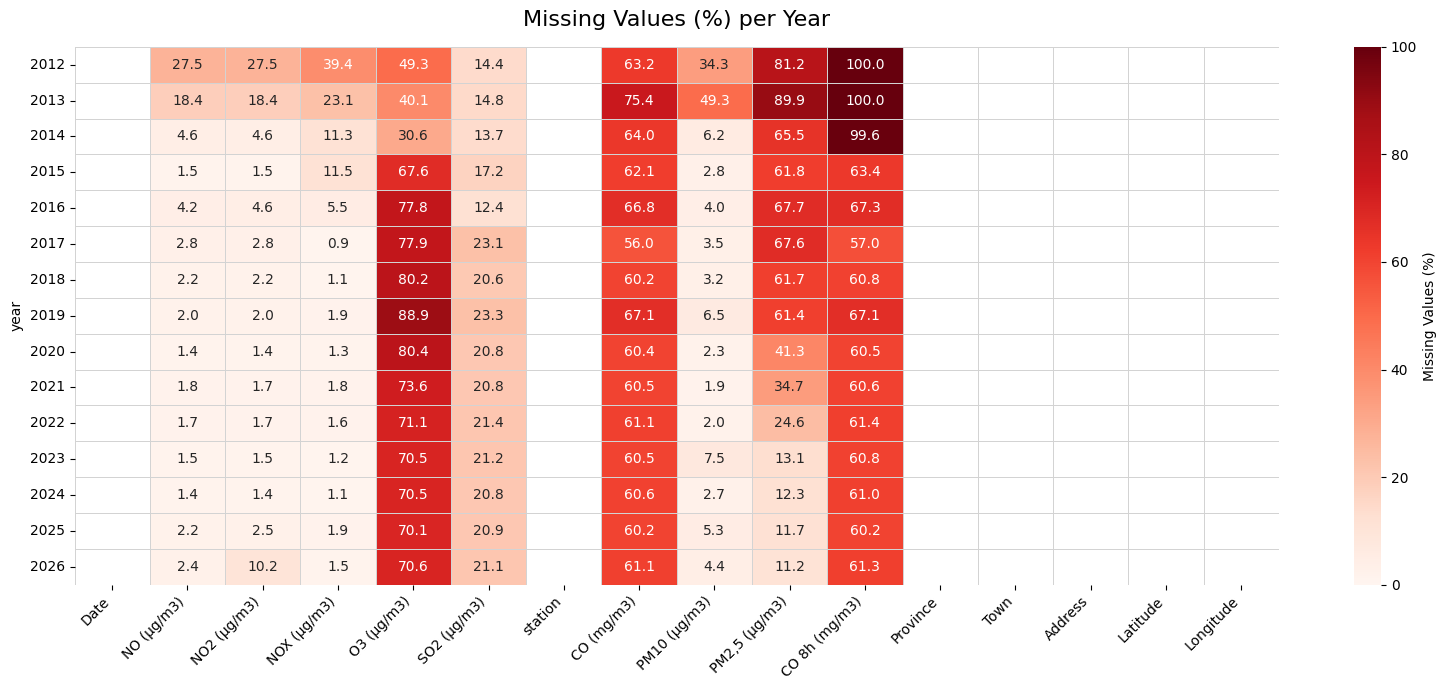

In [24]:
mask = missing_by_year == 0

plt.figure(figsize=(16, 7))

sns.heatmap(
    missing_by_year,
    mask=mask,                 # hide unnecessary cells
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing Values (%) per Year", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [25]:
pivot_missing = df.pivot_table(
    values="PM2,5 (µg/m3)",
    index="station",
    columns=df["Date"].dt.year,
    aggfunc=lambda x: x.isna().mean()*100
)
pivot_missing

Date,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,,,,,,
ABANTO,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ALGORTA_BBIZI2,100.000000,100.000000,1.917808,2.739726,NaN,3.287671,0.821918,NaN,1.639344,1.648352,6.722689,1.111111,6.010929,6.575342,6.349206
ALONSOTEGI,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,37.260274,21.917808,0.547945,11.748634,2.191781,1.587302
BARAKALDO,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,44.109589,3.278689,2.465753,3.013699,7.123288,0.819672,0.000000,1.587302
BASAURI,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,10.410959,2.465753,0.000000,5.753425,0.000000
ERANDIO,30.601093,96.986301,36.986301,4.109589,1.639344,3.835616,3.835616,0.547945,0.546448,0.821918,1.917808,13.972603,0.546448,0.000000,0.793651
MAZARREDO,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2.185792,0.000000,0.547945,0.000000,0.546448,1.095890,0.000000
MUSKIZ,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,96.712329,4.657534,0.000000,0.000000,0.000000
SANGRONIZ,84.065934,100.000000,12.602740,7.671233,2.185792,1.643836,7.945205,6.027397,1.912568,0.547945,1.369863,1.095890,0.546448,1.643836,1.587302


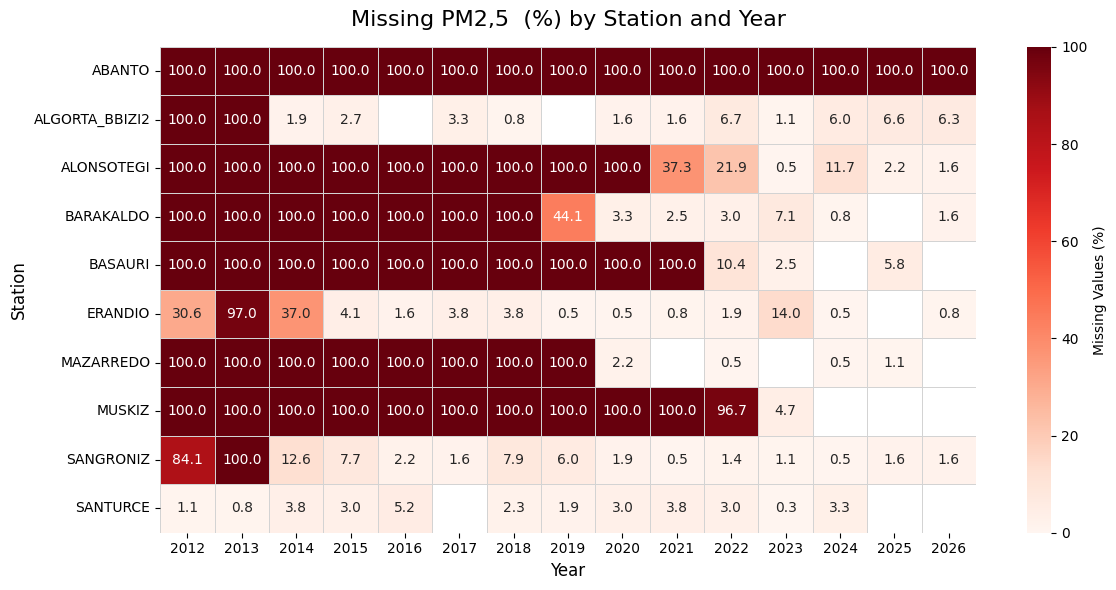

In [26]:
mask = pivot_missing == 0

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_missing,
    mask=mask,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing PM2,5  (%) by Station and Year", fontsize=16, pad=15)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
pivot_missing_co = df_70.pivot_table(
    values="CO (mg/m3)",
    index="station",
    columns=df_70["Date"].dt.year,
    aggfunc=lambda x: x.isna().mean()*100
)
pivot_missing_co

Date,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,,,,,,
ABANTO,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ALGORTA_BBIZI2,0.000000,4.109589,1.643836,13.972603,NaN,1.917808,0.273973,NaN,0.000000,1.648352,6.162465,1.666667,2.459016,0.000000,6.349206
ALONSOTEGI,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
BARAKALDO,14.480874,93.972603,2.191781,0.821918,0.000000,1.095890,0.000000,2.191781,0.000000,2.739726,0.547945,1.095890,0.546448,0.000000,0.000000
BASAURI,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ERANDIO,10.109290,7.397260,30.684932,2.465753,0.000000,0.547945,1.369863,0.273973,0.000000,0.273973,1.917808,0.547945,0.546448,0.547945,3.174603
MAZARREDO,12.324930,51.506849,5.205479,3.287671,1.639344,0.821918,1.917808,1.095890,4.098361,0.000000,1.369863,0.547945,2.185792,1.095890,1.587302
MUSKIZ,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
SANGRONIZ,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


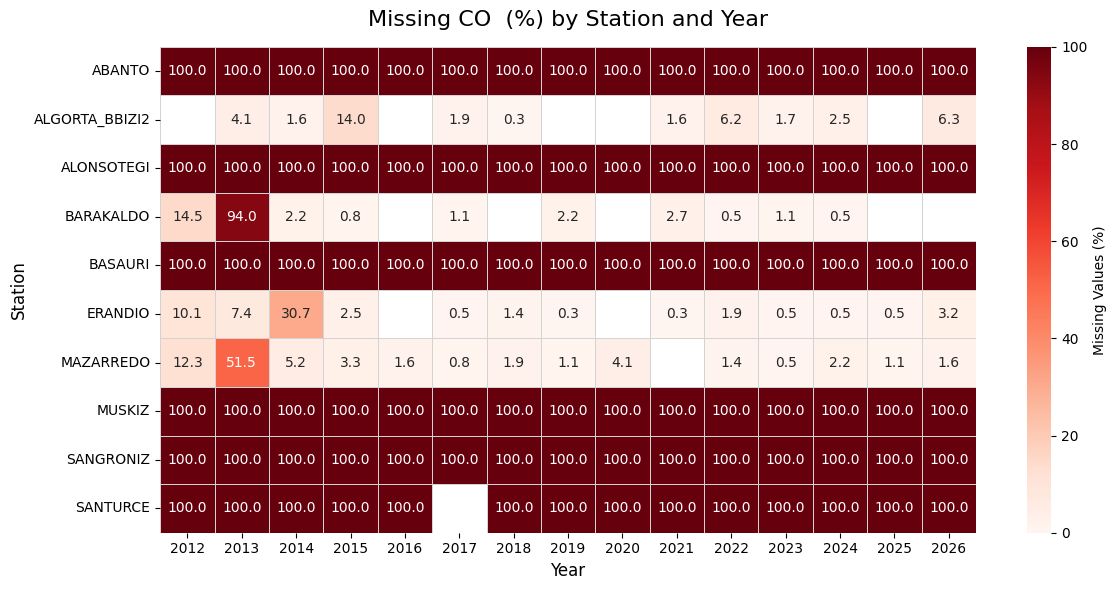

In [28]:
mask_co = pivot_missing_co == 0

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_missing_co,
    mask=mask_co,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing CO  (%) by Station and Year", fontsize=16, pad=15)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
pivot_missing_co8 = df_70.pivot_table(
    values="CO 8h (mg/m3)",
    index="station",
    columns=df_70["Date"].dt.year,
    aggfunc=lambda x: x.isna().mean()*100
)
pivot_missing_co8

Date,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,,,,,,
ABANTO,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ALGORTA_BBIZI2,100.0,100.0,98.904110,25.205479,NaN,4.931507,3.561644,NaN,0.000000,1.923077,6.442577,3.333333,4.644809,0.273973,6.349206
ALONSOTEGI,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
BARAKALDO,100.0,100.0,98.904110,1.095890,0.546448,2.465753,0.273973,2.465753,0.000000,3.287671,0.821918,1.917808,0.546448,0.273973,0.000000
BASAURI,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ERANDIO,100.0,100.0,99.178082,3.835616,0.273224,3.561644,3.013699,0.273973,0.546448,0.273973,3.287671,1.369863,1.639344,0.547945,5.555556
MAZARREDO,100.0,100.0,98.904110,3.835616,4.644809,2.465753,2.465753,1.369863,5.191257,0.547945,1.917808,0.547945,3.551913,1.369863,1.587302
MUSKIZ,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
SANGRONIZ,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


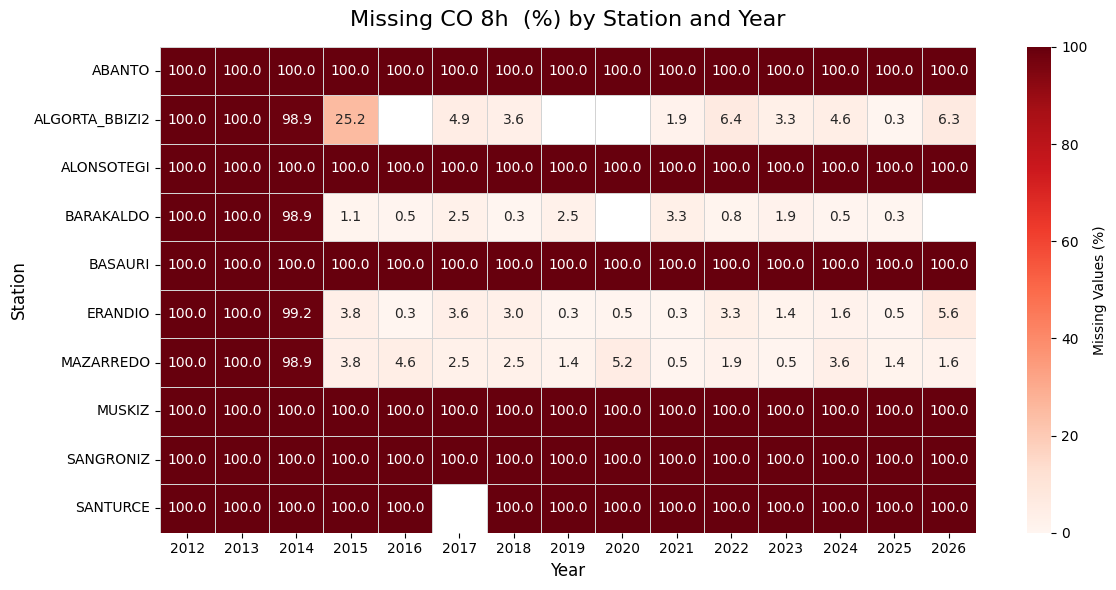

In [30]:
mask_co8 = pivot_missing_co8 == 0

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_missing_co8,
    mask=mask_co8,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing CO 8h  (%) by Station and Year", fontsize=16, pad=15)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [31]:
pivot_missing_o3 = df_70.pivot_table(
    values="O3 (µg/m3)",
    index="station",
    columns=df_70["Date"].dt.year,
    aggfunc=lambda x: x.isna().mean()*100
)
pivot_missing_o3

Date,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,,,,,,
ABANTO,85.344828,2.816901,0.273973,93.972603,100.000000,100.000000,100.000000,100.000000,100.000000,34.794521,1.917808,0.273973,2.185792,0.547945,0.000000
ALGORTA_BBIZI2,0.000000,0.547945,0.000000,3.013699,NaN,1.369863,0.000000,NaN,3.551913,0.549451,8.123249,1.111111,1.366120,0.000000,6.349206
ALONSOTEGI,1.366120,0.273973,0.000000,0.000000,0.546448,98.904110,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
BARAKALDO,100.000000,92.328767,1.917808,93.972603,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
BASAURI,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
ERANDIO,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
MAZARREDO,1.960784,6.027397,0.821918,92.328767,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
MUSKIZ,1.204819,0.000000,0.000000,0.821918,0.000000,0.821918,3.013699,0.547945,0.821918,0.000000,0.000000,2.465753,1.092896,0.000000,0.000000
SANGRONIZ,0.274725,0.000000,3.287671,92.328767,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


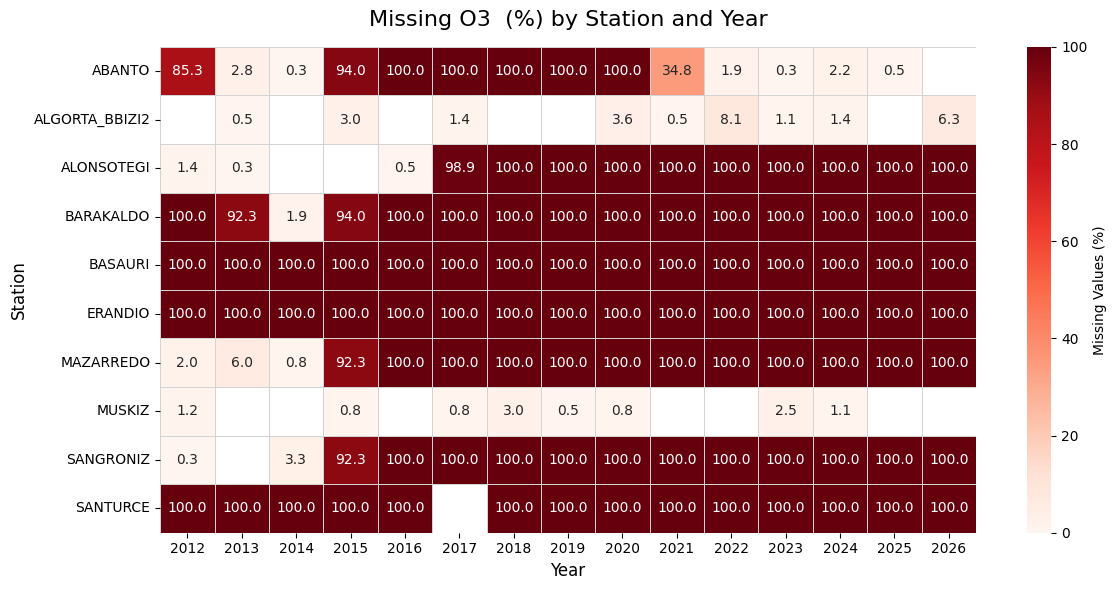

In [32]:
mask_o3 = pivot_missing_o3 == 0

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_missing_o3,
    mask=mask_o3,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Missing Values (%)"},
    vmin=0,
    vmax=100
)

plt.title("Missing O3  (%) by Station and Year", fontsize=16, pad=15)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Station", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In heatmaps for the years 2012–2014:

PM2.5 → 100% missing at several stations

8h CO → 100% missing in almost all years

CO → 60–90% missing

O3 → 50–100% missing

NOx → very high missing

NO → high missing

This is not random noise.

This is due to a lack of measurement infrastructure during those years.

From 2015 onwards, the quality improves significantly.

Your graphs show:

2015–2026 → much more complete data

More stable stations

Sensors functioning

Less structural missing data

This is a usable dataset.

In [33]:
df_2015_70 = df[df["Date"].dt.year >= 2015]
df_2015_70.head()

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),O3 (µg/m3),SO2 (µg/m3),year,station,CO (mg/m3),PM10 (µg/m3),...,SH2 (µg/m3),M-P-XILENO (µg/m3),CO 8h (mg/m3),Etilbenceno (µg/m3),O3 8h (µg/m3),Province,Town,Address,Latitude,Longitude
10847,2015-12-31,20.0,46.0,76.0,NaN,5.0,2015,ABANTO,NaN,11.0,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10848,2015-12-30,2.0,6.0,10.0,NaN,4.0,2015,ABANTO,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10849,2015-12-29,3.0,7.0,11.0,NaN,4.0,2015,ABANTO,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10850,2015-12-28,3.0,9.0,14.0,NaN,4.0,2015,ABANTO,NaN,11.0,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10851,2015-12-27,3.0,10.0,14.0,NaN,6.0,2015,ABANTO,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


M-P-XILENO (µg/m3)     91.095126
Etilbenceno (µg/m3)    90.797470
Ortoxileno (µg/m3)     90.286494
NH3 (µg/m3)            89.859854
SH2 (µg/m3)            85.390053
Benceno (µg/m3)        81.617264
Tolueno (µg/m3)        81.381620
O3 8h (µg/m3)          75.686469
O3 (µg/m3)             75.021704
CO 8h (mg/m3)          61.773533
CO (mg/m3)             61.341932
PM2,5 (µg/m3)          40.024805
SO2 (µg/m3)            20.257968
PM10 (µg/m3)            3.790153
NOX (µg/m3)             2.644177
NO2 (µg/m3)             2.329158
NO (µg/m3)              2.036463
station                 0.000000
year                    0.000000
Date                    0.000000
Province                0.000000
Town                    0.000000
Address                 0.000000
Latitude                0.000000
Longitude               0.000000
dtype: float64


Text(0, 0.5, 'Percentage of Missing Values')

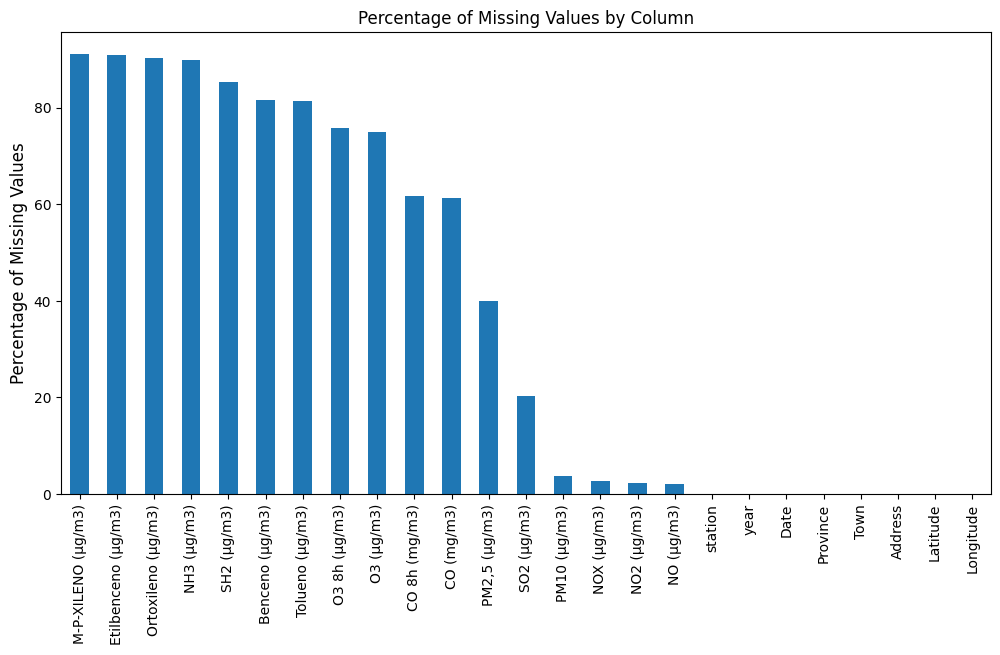

In [34]:
missing_percent_2015_70 = df_2015_70.isna().mean().sort_values(ascending=False) * 100
print (missing_percent_2015_70)
missing_percent_2015_70.plot(kind="bar", figsize=(12, 6))
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percentage of Missing Values", fontsize=12)


CO, CO₂ 8h, and O₃ values ​​were excluded due to the large number of missing values ​​and limited coverage across all stations.

O₃ was further excluded because its measurements were only available for a small subset of stations, making it unsuitable for a consistent metropolitan-scale comparison.

In [35]:
cols_to_drop2 = missing_percent_2015_70[missing_percent_2015_70 > 60].index
cols_to_drop2

Index(['M-P-XILENO (µg/m3)', 'Etilbenceno (µg/m3)', 'Ortoxileno (µg/m3)',
       'NH3 (µg/m3)', 'SH2 (µg/m3)', 'Benceno (µg/m3)', 'Tolueno (µg/m3)',
       'O3 8h (µg/m3)', 'O3 (µg/m3)', 'CO 8h (mg/m3)', 'CO (mg/m3)'],
      dtype='str')

In [36]:
df_c1 = df_2015_70.drop(columns=cols_to_drop2)
df_c1.head()

,Date,NO (µg/m3),NO2 (µg/m3),NOX (µg/m3),SO2 (µg/m3),year,station,PM10 (µg/m3),"PM2,5 (µg/m3)",Province,Town,Address,Latitude,Longitude
10847,2015-12-31,20.0,46.0,76.0,5.0,2015,ABANTO,11.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10848,2015-12-30,2.0,6.0,10.0,4.0,2015,ABANTO,4.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10849,2015-12-29,3.0,7.0,11.0,4.0,2015,ABANTO,3.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10850,2015-12-28,3.0,9.0,14.0,4.0,2015,ABANTO,11.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10851,2015-12-27,3.0,10.0,14.0,6.0,2015,ABANTO,5.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


PM2,5 (µg/m3)    40.024805
SO2 (µg/m3)      20.257968
PM10 (µg/m3)      3.790153
NOX (µg/m3)       2.644177
NO2 (µg/m3)       2.329158
NO (µg/m3)        2.036463
year              0.000000
Date              0.000000
station           0.000000
Province          0.000000
Town              0.000000
Address           0.000000
Latitude          0.000000
Longitude         0.000000
dtype: float64


Text(0, 0.5, 'Percentage of Missing Values')

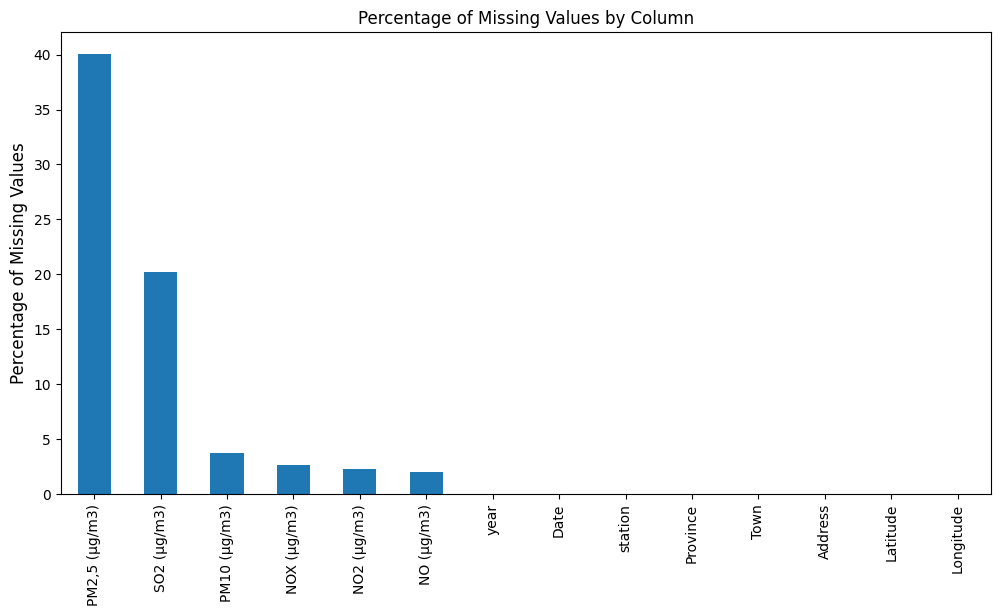

In [37]:
missing_percent_clean = df_c1.isna().mean().sort_values(ascending=False) * 100
print (missing_percent_clean)
missing_percent_clean.plot(kind="bar", figsize=(12, 6))
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percentage of Missing Values", fontsize=12)

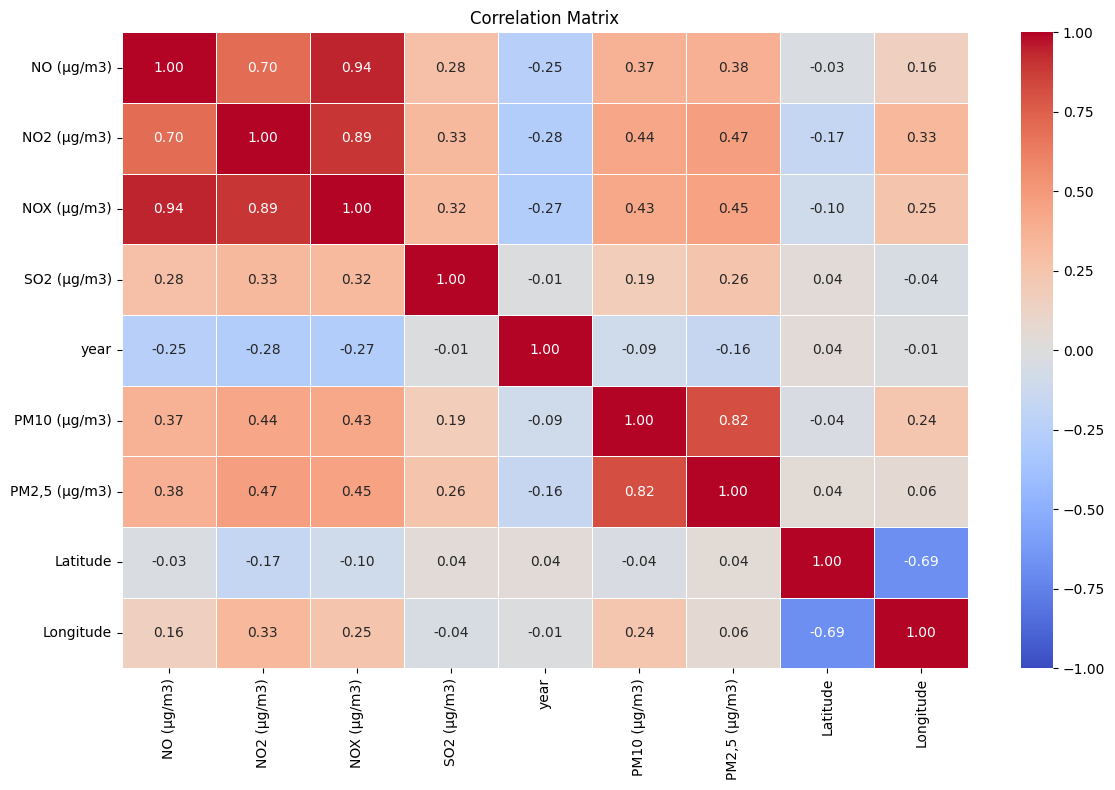

In [38]:
corr_matrix = df_c1.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Due to the strong correlation and chemical dependence between NO, NO2, and NOx, only NO2 was retained in the final modeling dataset to reduce multicollinearity and improve interpretability.

In [39]:
df_c2= df_c1.drop(columns=["NO (µg/m3)", "NOX (µg/m3)"])
df_c2.head()

,Date,NO2 (µg/m3),SO2 (µg/m3),year,station,PM10 (µg/m3),"PM2,5 (µg/m3)",Province,Town,Address,Latitude,Longitude
10847,2015-12-31,46.0,5.0,2015,ABANTO,11.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10848,2015-12-30,6.0,4.0,2015,ABANTO,4.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10849,2015-12-29,7.0,4.0,2015,ABANTO,3.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10850,2015-12-28,9.0,4.0,2015,ABANTO,11.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156
10851,2015-12-27,10.0,6.0,2015,ABANTO,5.0,NaN,Bizkaia,Abanto y Ciérvana-Abanto Zierbena,"Avda. del Minero, 2. Ayuntamiento",43.320474,-3.074156


PM2,5 (µg/m3)    40.024805
SO2 (µg/m3)      20.257968
PM10 (µg/m3)      3.790153
NO2 (µg/m3)       2.329158
year              0.000000
Date              0.000000
station           0.000000
Province          0.000000
Town              0.000000
Address           0.000000
Latitude          0.000000
Longitude         0.000000
dtype: float64


Text(0, 0.5, 'Percentage of Missing Values')

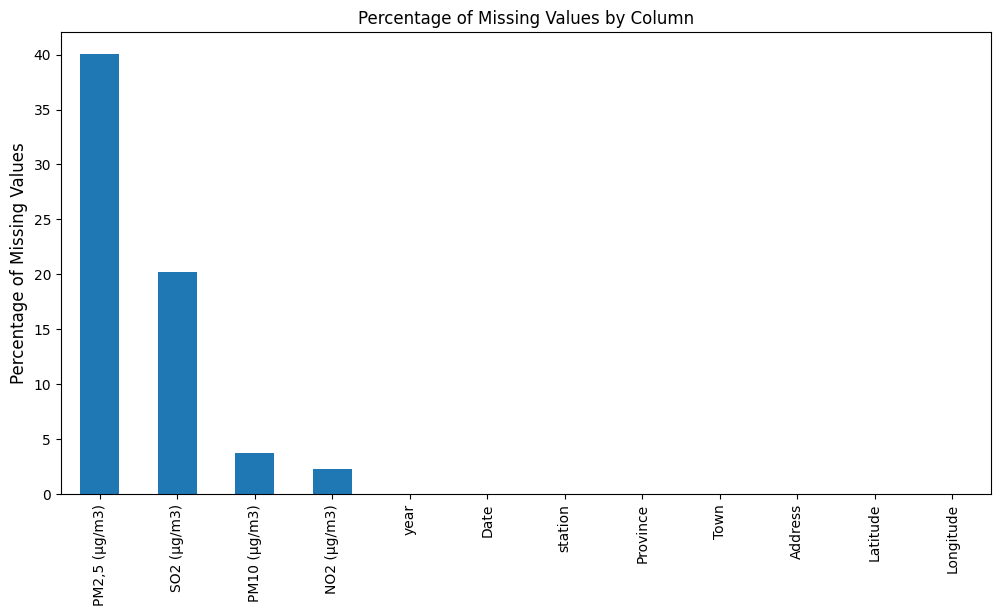

In [40]:
missing_percent_c2 = (
    df_c2.isna()
    .mean()
    .sort_values(ascending=False) * 100
)
print (missing_percent_c2)
missing_percent_c2.plot(kind="bar", figsize=(12, 6))
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percentage of Missing Values", fontsize=12)

In [41]:
cols_missing = ["SO2 (µg/m3)", "PM2,5 (µg/m3)", "PM10 (µg/m3)" , "NO2 (µg/m3)"]

df_missing = df_c2[df_c2[cols_missing].isna().any(axis=1)][
    ["station", "Date", "Town"] + cols_missing
]

df_missing

,station,Date,Town,SO2 (µg/m3),"PM2,5 (µg/m3)",PM10 (µg/m3),NO2 (µg/m3)
10847,ABANTO,2015-12-31,Abanto y Ciérvana-Abanto Zierbena,5.0,NaN,11.0,46.0
10848,ABANTO,2015-12-30,Abanto y Ciérvana-Abanto Zierbena,4.0,NaN,4.0,6.0
10849,ABANTO,2015-12-29,Abanto y Ciérvana-Abanto Zierbena,4.0,NaN,3.0,7.0
10850,ABANTO,2015-12-28,Abanto y Ciérvana-Abanto Zierbena,4.0,NaN,11.0,9.0
10851,ABANTO,2015-12-27,Abanto y Ciérvana-Abanto Zierbena,6.0,NaN,5.0,10.0
...,...,...,...,...,...,...,...
52127,SANGRONIZ,2026-01-05,Sondika,NaN,9.0,14.0,29.0
52128,SANGRONIZ,2026-01-04,Sondika,NaN,5.0,10.0,15.0
52129,SANGRONIZ,2026-01-03,Sondika,NaN,5.0,5.0,9.0
52130,SANGRONIZ,2026-01-02,Sondika,NaN,8.0,10.0,22.0


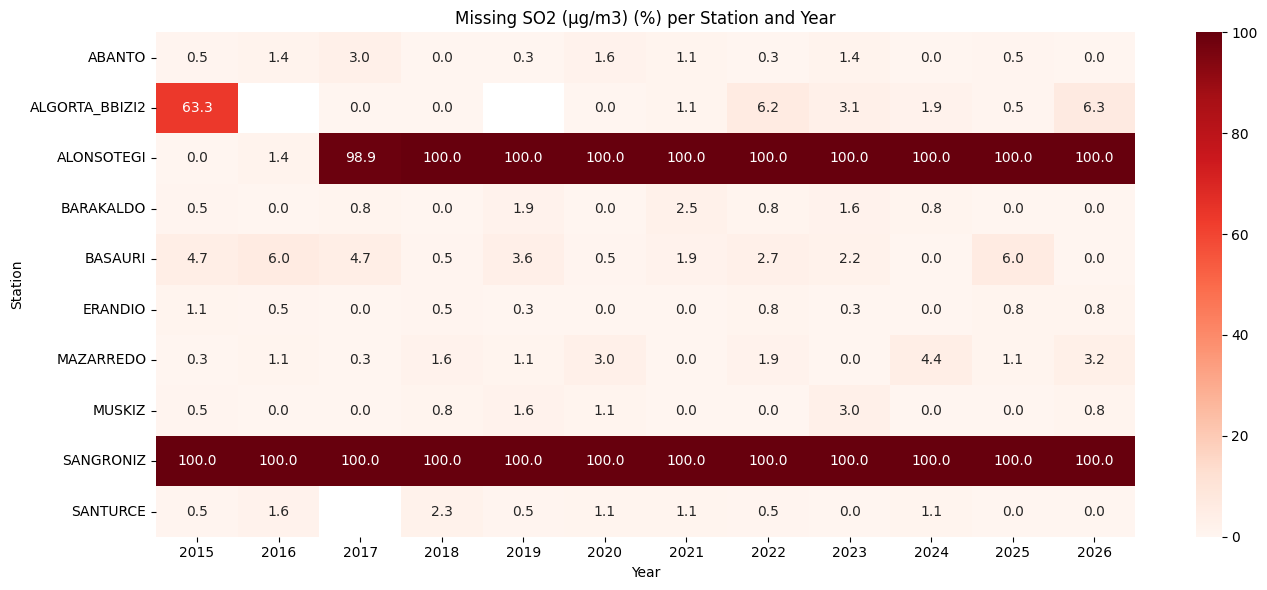

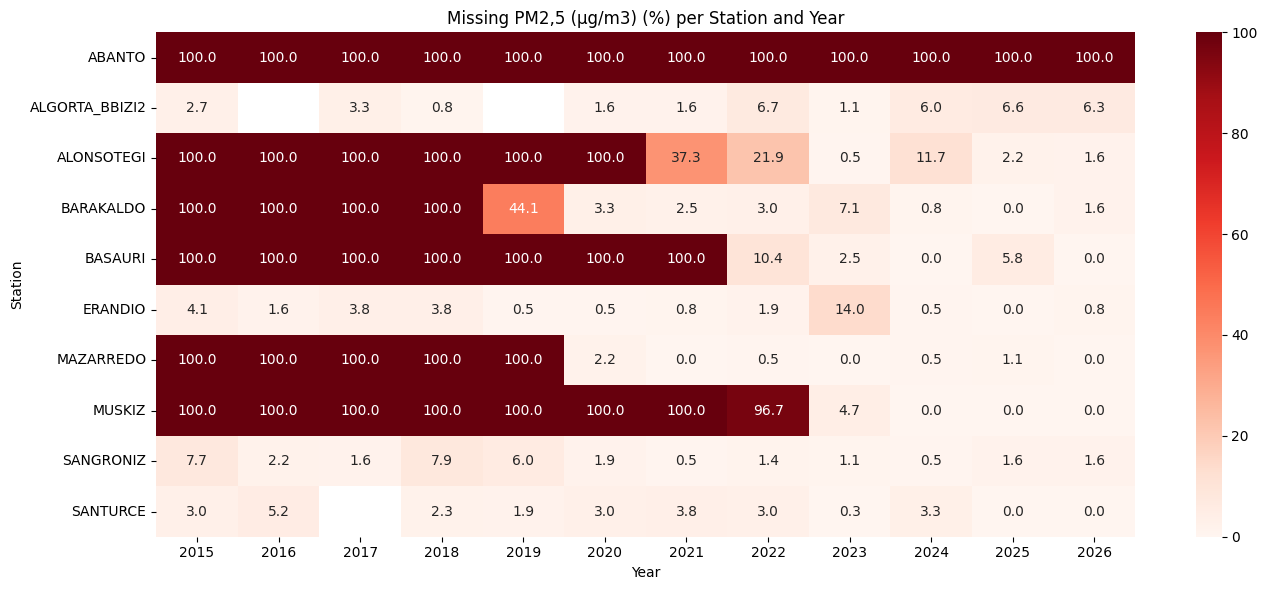

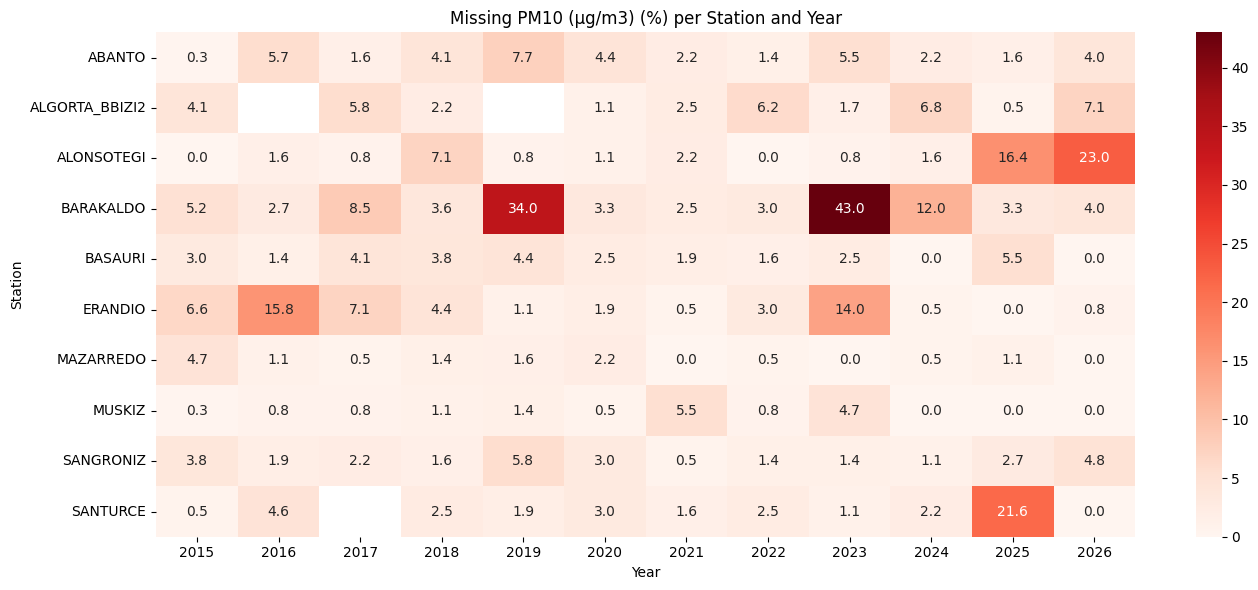

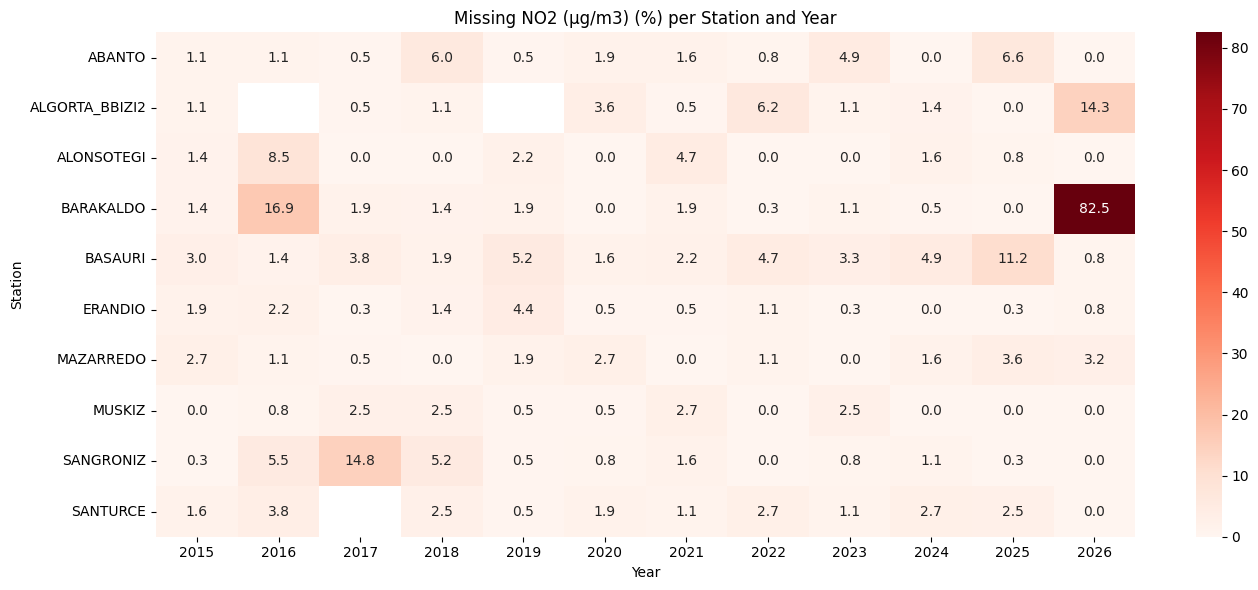

In [42]:
cols_missing = ["SO2 (µg/m3)", "PM2,5 (µg/m3)", "PM10 (µg/m3)" , "NO2 (µg/m3)"]

for col in cols_missing:
    pivot_missing = df_c2.pivot_table(
        values=col,
        index="station",
        columns="year",
        aggfunc=lambda x: x.isna().mean() * 100
    )

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot_missing, annot=True, fmt=".1f", cmap="Reds")
    plt.title(f"Missing {col} (%) per Station and Year")
    plt.xlabel("Year")
    plt.ylabel("Station")
    plt.tight_layout()
    plt.show()

SANGRONIZ: SO2 almost 100% missing. PM2.5: has data but poor coverage

ABANTO: PM2.5 100% missing in all years. Bad for ML,Incomplete for EDA ,Breaks spatial comparison

ALONSOTEGI: SO2 almost 100% missing since 2017  , M2.5 100% missing for several years

A station that is almost completely missing one of the main pollutants:

Breaks correlation
Weakens ML
Induces bias
Requires heavy imputation

✅ Barakaldo

Very good.

urban-industrial
good coverage
strong pollutants
high variability

great for the project.

✅ BASAURI

good and stable.

urban traffic
low missing
suitable for trend analysis

✅ MAZARREDO

This is extremely important.

Because:

Bilbao
urban core
representative of downtown

very valuable for Smart City.

✅ MUSKIZ

very valuable data.
industrial area
high PM probability
great contrast with downtown

In [43]:
bad_stations = ["SANGRONIZ", "ABANTO", "ALONSOTEGI"]

df_c3 = df_c2[~df_c2["station"].isin(bad_stations)]
df_c3.head()

,Date,NO2 (µg/m3),SO2 (µg/m3),year,station,PM10 (µg/m3),"PM2,5 (µg/m3)",Province,Town,Address,Latitude,Longitude
11212,2015-12-31,26.0,NaN,2015,ALGORTA_BBIZI2,20.0,10.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
11213,2015-12-30,5.0,NaN,2015,ALGORTA_BBIZI2,14.0,5.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
11214,2015-12-29,11.0,NaN,2015,ALGORTA_BBIZI2,10.0,4.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
11215,2015-12-28,10.0,NaN,2015,ALGORTA_BBIZI2,19.0,9.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
11216,2015-12-27,16.0,NaN,2015,ALGORTA_BBIZI2,9.0,7.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782


In [44]:
df_c3.info()

<class 'pandas.DataFrame'>
Index: 27883 entries, 11212 to 52257
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           27883 non-null  datetime64[us]
 1   NO2 (µg/m3)    27219 non-null  float64       
 2   SO2 (µg/m3)    27311 non-null  float64       
 3   year           27883 non-null  int64         
 4   station        27883 non-null  str           
 5   PM10 (µg/m3)   26741 non-null  float64       
 6   PM2,5 (µg/m3)  18475 non-null  float64       
 7   Province       27883 non-null  str           
 8   Town           27883 non-null  str           
 9   Address        27883 non-null  str           
 10  Latitude       27883 non-null  float64       
 11  Longitude      27883 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(4)
memory usage: 4.3 MB


In [53]:
df_c3.isna().sum()

Date                0
NO2 (µg/m3)       664
SO2 (µg/m3)       572
year                0
station             0
PM10 (µg/m3)     1142
PM2,5 (µg/m3)    9408
Province            0
Town                0
Address             0
Latitude            0
Longitude           0
dtype: int64

In [54]:
df_c3['Date'] = pd.to_datetime(df_c3['Date'])

df_indexed = df_c3.set_index(['station', 'Date'])

full_date_range = pd.date_range(start=df_c3['Date'].min(), end=df_c3['Date'].max(), freq='D')

all_stations = df_c3['station'].unique()
new_index = pd.MultiIndex.from_product([all_stations, full_date_range], names=['station', 'Date'])

df_filled = df_indexed.reindex(new_index).reset_index()

df_filled.isna().sum()

station              0
Date                 0
NO2 (µg/m3)       1789
SO2 (µg/m3)       1697
year              1125
PM10 (µg/m3)      2267
PM2,5 (µg/m3)    10533
Province          1125
Town              1125
Address           1125
Latitude          1125
Longitude         1125
dtype: int64

In [56]:
df_filled = df_filled.sort_values(['station', 'Date'])
df_filled[['Province', 'Town', 'Latitude', 'Longitude', 'Address']] = df_filled.groupby('station')[['Province', 'Town', 'Latitude', 'Longitude', 'Address']].ffill().bfill()

df_filled.isna().sum()

station              0
Date                 0
NO2 (µg/m3)       1789
SO2 (µg/m3)       1697
year              1125
PM10 (µg/m3)      2267
PM2,5 (µg/m3)    10533
Province             0
Town                 0
Address              0
Latitude             0
Longitude            0
dtype: int64

Missing values were handled using Multiple Imputation by Chained Equations (MICE) combined with temporal interpolation. PM2.5 presented the highest missingness (~34%), while NO2, SO2 and PM10 had less than 5% missing observations. Because PM2.5 showed a strong correlation with PM10 across all monitoring stations (r = 0.69–0.95), the imputation process was considered statistically justified for exploratory analysis, dashboard development and predictive modeling.

Filling missing values with using Iterative Imputer (MICE)

In [57]:
num_cols = df_filled.select_dtypes(include="number").columns
cat_cols = df_filled.select_dtypes(exclude="number").columns
print (num_cols)
print (cat_cols)

Index(['NO2 (µg/m3)', 'SO2 (µg/m3)', 'year', 'PM10 (µg/m3)', 'PM2,5 (µg/m3)',
       'Latitude', 'Longitude'],
      dtype='str')
Index(['station', 'Date', 'Province', 'Town', 'Address'], dtype='str')


In [ ]:
#!pip install scikit-learn

In [58]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=20, random_state=42)

df_imputed = []


for st in df_filled["station"].unique():
    sub = df_filled[df_filled["station"] == st].copy()

    # only columns that exist
    existing_cols = [c for c in num_cols if c in sub.columns]

    # Eliminate columns that are completely NaN
    non_empty_cols = [c for c in existing_cols if not sub[c].isna().all()]

    # Run MICE only on non-empty columns
    sub[non_empty_cols] = imputer.fit_transform(sub[non_empty_cols])

    df_imputed.append(sub)

In [59]:
df_final_imputed = pd.concat(df_imputed).sort_index()
df_final_imputed.head()

,station,Date,NO2 (µg/m3),SO2 (µg/m3),year,PM10 (µg/m3),"PM2,5 (µg/m3)",Province,Town,Address,Latitude,Longitude
0,ALGORTA_BBIZI2,2015-01-01,47.0,9.0,2015.0,25.0,28.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
1,ALGORTA_BBIZI2,2015-01-02,56.0,8.0,2015.0,24.0,18.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
2,ALGORTA_BBIZI2,2015-01-03,48.0,8.0,2015.0,33.0,21.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
3,ALGORTA_BBIZI2,2015-01-04,43.0,7.0,2015.0,31.0,23.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
4,ALGORTA_BBIZI2,2015-01-05,29.0,5.0,2015.0,18.0,11.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782


In [60]:
df_final_imputed.isnull().sum()

station          0
Date             0
NO2 (µg/m3)      0
SO2 (µg/m3)      0
year             0
PM10 (µg/m3)     0
PM2,5 (µg/m3)    0
Province         0
Town             0
Address          0
Latitude         0
Longitude        0
dtype: int64

In [61]:
df_final_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 29008 entries, 0 to 29007
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   station        29008 non-null  str           
 1   Date           29008 non-null  datetime64[us]
 2   NO2 (µg/m3)    29008 non-null  float64       
 3   SO2 (µg/m3)    29008 non-null  float64       
 4   year           29008 non-null  float64       
 5   PM10 (µg/m3)   29008 non-null  float64       
 6   PM2,5 (µg/m3)  29008 non-null  float64       
 7   Province       29008 non-null  str           
 8   Town           29008 non-null  str           
 9   Address        29008 non-null  str           
 10  Latitude       29008 non-null  float64       
 11  Longitude      29008 non-null  float64       
dtypes: datetime64[us](1), float64(7), str(4)
memory usage: 4.3 MB


In [62]:
df_final_imputed.drop(columns=['Province_y', 'Town_y', 'Address_y',"year"], inplace=True, errors='ignore')

In [63]:
df_final_imputed.rename(columns={
    'Province_x': 'Province',
    'Town_x': 'Town',
    'Address_x': 'Address',
    'Latitude_y': 'Latitude',
    'Longitude_y': 'Longitude',
    'NO2 (µg/m3)': 'NO2',
    'SO2 (µg/m3)': 'SO2',
    'PM10 (µg/m3)': 'PM10',
    'PM2,5 (µg/m3)': 'PM2.5'
}, inplace=True)
df_final_imputed.head()

,station,Date,NO2,SO2,PM10,PM2.5,Province,Town,Address,Latitude,Longitude
0,ALGORTA_BBIZI2,2015-01-01,47.0,9.0,25.0,28.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
1,ALGORTA_BBIZI2,2015-01-02,56.0,8.0,24.0,18.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
2,ALGORTA_BBIZI2,2015-01-03,48.0,8.0,33.0,21.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
3,ALGORTA_BBIZI2,2015-01-04,43.0,7.0,31.0,23.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
4,ALGORTA_BBIZI2,2015-01-05,29.0,5.0,18.0,11.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782


In [64]:
df_final_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 29008 entries, 0 to 29007
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   station    29008 non-null  str           
 1   Date       29008 non-null  datetime64[us]
 2   NO2        29008 non-null  float64       
 3   SO2        29008 non-null  float64       
 4   PM10       29008 non-null  float64       
 5   PM2.5      29008 non-null  float64       
 6   Province   29008 non-null  str           
 7   Town       29008 non-null  str           
 8   Address    29008 non-null  str           
 9   Latitude   29008 non-null  float64       
 10  Longitude  29008 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(4)
memory usage: 4.0 MB


In [65]:
df_final_imputed = df_final_imputed.loc[:, ~df_final_imputed.columns.duplicated()]
df_final_imputed.head()

,station,Date,NO2,SO2,PM10,PM2.5,Province,Town,Address,Latitude,Longitude
0,ALGORTA_BBIZI2,2015-01-01,47.0,9.0,25.0,28.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
1,ALGORTA_BBIZI2,2015-01-02,56.0,8.0,24.0,18.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
2,ALGORTA_BBIZI2,2015-01-03,48.0,8.0,33.0,21.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
3,ALGORTA_BBIZI2,2015-01-04,43.0,7.0,31.0,23.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782
4,ALGORTA_BBIZI2,2015-01-05,29.0,5.0,18.0,11.0,Bizkaia,Getxo,"Carretera de Galea, s/n",43.362056,-3.022782


In [66]:
cols = [
    "Date",
    "station",
    "Town",
    "Province",
    "Latitude",
    "Longitude",
    "NO2",
    "PM10",
    "PM2.5",
    "SO2"
]

df_final_imputed = df_final_imputed[cols]
df_final_imputed.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0


In [67]:
df_final = df_final_imputed.sort_values(
    by=["station", "Date"]
).reset_index(drop=True)
df_final.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0


In [68]:
output_path = root / "data" / "processed"

output_file = output_path / "cleaned_air_quality_bilbao_2015_2026.csv"

df_final.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"File saved successfully at: {output_file}")

File saved successfully at: C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\data\processed\cleaned_air_quality_bilbao_2015_2026.csv
